# Outlier detection

## Point outlier

In [8]:
import numpy as np

# Sample data
data = [-10, 20, 30, 40, 50, 60, 70, 80, 90, 1000]

# Convert to numpy array for convenience
data = np.array(data)

In [10]:
# Calculate Q1 (25th percentile)
Q1 = np.percentile(data, 25)

# Calculate Q3 (75th percentile)
Q3 = np.percentile(data, 75)

# Calculate IQR
IQR = Q3 - Q1
# print("IQR = ",IQR)

# Calculate the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = [x for x in data if x < lower_bound or x > upper_bound]

# Output results
print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)
print("Lower Bound for Outliers:", lower_bound)
print("Upper Bound for Outliers:", upper_bound)
print("Outliers:", outliers)

Q1 (25th percentile): 32.5
Q3 (75th percentile): 77.5
IQR: 45.0
Lower Bound for Outliers: -35.0
Upper Bound for Outliers: 145.0
Outliers: [1000]


## Contextual outliers

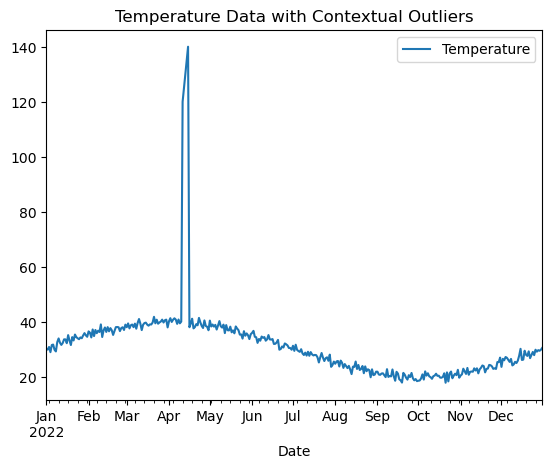

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data: daily temperatures in Fahrenheit over a year (example)
dates = pd.date_range("2022-01-01", periods=365)
temperatures = [30 + np.sin(i * 2 * np.pi / 365) * 10 + np.random.randn() for i in range(365)]

# Injecting some contextual outliers (temperatures higher than 120°F in winter)
temperatures[100:105] = [120, 125, 130, 135, 140]

# Create a DataFrame
df = pd.DataFrame({"Date": dates, "Temperature": temperatures})

# Visualize the data
df.plot(x="Date", y="Temperature", title="Temperature Data with Contextual Outliers")
plt.show()


## Collection outliers

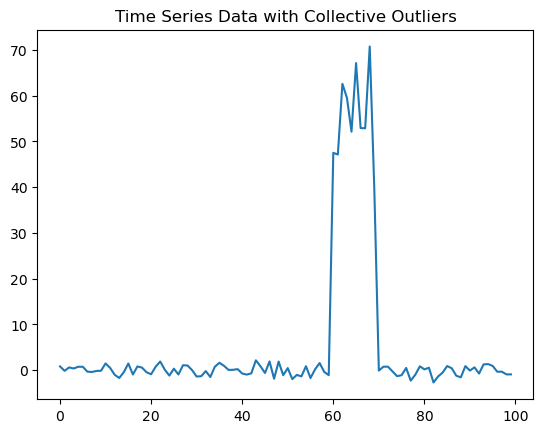

Collective Outliers indices: (array([59, 61, 64, 67]),)


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample time series data
data = np.random.normal(loc=0, scale=1, size=100)  # Normal distribution
data[60:70] = np.random.normal(loc=50, scale=10, size=10)  # Inject collective outlier

# Create a DataFrame
df = pd.DataFrame({"Time": range(100), "Value": data})

# Visualize the time series data
plt.plot(df["Time"], df["Value"])
plt.title("Time Series Data with Collective Outliers")
plt.show()

# Identify collective outliers using rolling window or difference
diff = np.diff(df['Value'])
outliers = np.where(diff > 10)  # Difference greater than a threshold (for example, 10)
print("Collective Outliers indices:", outliers)
